In [1]:
from google.colab import files
import pandas as pd, io

In [2]:
uploaded = files.upload()


Saving dataset_cdc.csv to dataset_cdc.csv


In [3]:
cdc_filename = list(uploaded.keys())[0]


In [4]:
cdc_raw = pd.read_csv(io.BytesIO(uploaded[cdc_filename]))


In [5]:
print(cdc_raw.shape)


(17972, 8)


In [6]:
cdc_raw.head()


,Notes,County,County Code,Year,Year Code,Deaths,Population,Crude Rate
0,NaN,"Autauga County, AL",1001.0,2018.0,2018.0,164.0,55601,295.0
1,NaN,"Autauga County, AL",1001.0,2019.0,2019.0,181.0,55869,324.0
2,NaN,"Autauga County, AL",1001.0,2020.0,2020.0,216.0,56145,384.7
3,NaN,"Autauga County, AL",1001.0,2021.0,2021.0,199.0,59095,336.7
4,NaN,"Autauga County, AL",1001.0,2022.0,2022.0,187.0,59759,312.9


In [7]:
need_cols = ['County', 'County Code', 'Year', 'Deaths', 'Population', 'Crude Rate']


In [8]:
cdc = (
    cdc_raw.loc[:, need_cols]
            [cdc_raw['Year'] == 2022]
            .copy()
)
cdc.head()

,County,County Code,Year,Deaths,Population,Crude Rate
4,"Autauga County, AL",1001.0,2022.0,187.0,59759,312.9
10,"Baldwin County, AL",1003.0,2022.0,758.0,246435,307.6
16,"Barbour County, AL",1005.0,2022.0,115.0,24706,465.5
22,"Bibb County, AL",1007.0,2022.0,105.0,22005,477.2
28,"Blount County, AL",1009.0,2022.0,261.0,59512,438.6


In [9]:
cdc['Population'] = pd.to_numeric(cdc['Population'], errors='coerce')
cdc['Crude Rate'] = pd.to_numeric(cdc['Crude Rate'], errors='coerce')

In [10]:
cdc['Deaths'] = pd.to_numeric(cdc['Deaths'], errors='coerce')


In [11]:
cdc['FIPS'] = pd.to_numeric(cdc['County Code'], errors='coerce').astype('Int64')
cdc = cdc[cdc['FIPS'].notna() & (cdc['FIPS'] != 0)]
cdc['FIPS'] = cdc['FIPS'].astype(int)

In [12]:
cdc = cdc.dropna(subset=['Deaths', 'Population', 'Crude Rate']).copy()


In [13]:
cdc.head()


,County,County Code,Year,Deaths,Population,Crude Rate,FIPS
4,"Autauga County, AL",1001.0,2022.0,187.0,59759.0,312.9,1001
10,"Baldwin County, AL",1003.0,2022.0,758.0,246435.0,307.6,1003
16,"Barbour County, AL",1005.0,2022.0,115.0,24706.0,465.5,1005
22,"Bibb County, AL",1007.0,2022.0,105.0,22005.0,477.2,1007
28,"Blount County, AL",1009.0,2022.0,261.0,59512.0,438.6,1009


In [14]:
cdc = cdc.rename(columns={
    'County': 'County',
    'Deaths': 'Deaths',
    'Population': 'Population',
    'Crude Rate': 'MortalityRate'
})[['FIPS','County','Deaths','Population','MortalityRate']]

cdc.head()

,FIPS,County,Deaths,Population,MortalityRate
4,1001,"Autauga County, AL",187.0,59759.0,312.9
10,1003,"Baldwin County, AL",758.0,246435.0,307.6
16,1005,"Barbour County, AL",115.0,24706.0,465.5
22,1007,"Bibb County, AL",105.0,22005.0,477.2
28,1009,"Blount County, AL",261.0,59512.0,438.6


In [15]:
county_state = cdc['County'].str.rsplit(', ', n=1, expand=True)
cdc['CountyName'] = county_state[0]
cdc['State'] = county_state[1]

In [16]:
cdc[['FIPS','CountyName','State','Deaths','Population','MortalityRate']].head()


,FIPS,CountyName,State,Deaths,Population,MortalityRate
4,1001,Autauga County,AL,187.0,59759.0,312.9
10,1003,Baldwin County,AL,758.0,246435.0,307.6
16,1005,Barbour County,AL,115.0,24706.0,465.5
22,1007,Bibb County,AL,105.0,22005.0,477.2
28,1009,Blount County,AL,261.0,59512.0,438.6


In [18]:
print("Rows after cleaning:", len(cdc))
print("Unique states:", cdc['State'].nunique())

Rows after cleaning: 2766
Unique states: 50


In [19]:
print(cdc[['Deaths','Population','MortalityRate']].describe())


             Deaths    Population  MortalityRate
count   2766.000000  2.766000e+03    2766.000000
mean     335.714751  1.187038e+05     371.501518
std      871.556254  3.513126e+05     115.538647
min       20.000000  2.475000e+03      85.000000
25%       59.000000  1.512700e+04     288.950000
50%      118.000000  3.154650e+04     364.000000
75%      276.250000  8.290800e+04     443.275000
max    24045.000000  9.721138e+06    1056.600000


In [20]:
bad = cdc[(cdc['Population']<=0) | (cdc['MortalityRate']<=0)]
print("Rows with non-positive population or mortality rate:", len(bad))

Rows with non-positive population or mortality rate: 0


In [21]:
cdc_outname = "CDC_HeartDisease_2022_CLEAN_from_raw.csv"


In [22]:
cdc.to_csv(cdc_outname, index=False)


In [23]:
files.download(cdc_outname)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
uploaded = files.upload()


Saving dataset_chr.csv to dataset_chr.csv


In [25]:
chr_filename = list(uploaded.keys())[0]
chr_raw = pd.read_csv(io.BytesIO(uploaded[chr_filename]))
print(chr_raw.shape)

(3205, 796)


/tmp/ipython-input-1069903187.py:2: DtypeWarning: Columns (0,1,2,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263

In [26]:
chr_raw.head()


,State FIPS Code,County FIPS Code,5-digit FIPS Code,State Abbreviation,Name,Release Year,County Clustered (Yes=1/No=0),Premature Death raw value,Premature Death numerator,Premature Death denominator,...,% Rural raw value,% Rural numerator,% Rural denominator,% Rural CI low,% Rural CI high,Population raw value,Population numerator,Population denominator,Population CI low,Population CI high
0,statecode,countycode,fipscode,state,county,year,county_clustered,v001_rawvalue,v001_numerator,v001_denominator,...,v058_rawvalue,v058_numerator,v058_denominator,v058_cilow,v058_cihigh,v051_rawvalue,v051_numerator,v051_denominator,v051_cilow,v051_cihigh
1,00,000,00000,US,United States,2025,NaN,8351.7365494,4763989,925367214,...,0.2000313707,66300254,331449281,NaN,NaN,334914895,NaN,NaN,NaN,NaN
2,01,000,01000,AL,Alabama,2025,NaN,11853.247248,102760,13958454,...,0.4226276049,2123399,5024279,NaN,NaN,5108468,NaN,NaN,NaN,NaN
3,01,001,01001,AL,Autauga County,2025,1,9938.2633823,1008,163064,...,0.406768132,23920,58805,NaN,NaN,60342,NaN,NaN,NaN,NaN
4,01,003,01003,AL,Baldwin County,2025,1,8957.1126859,3944,653515,...,0.3758645536,87113,231767,NaN,NaN,253507,NaN,NaN,NaN,NaN


In [27]:
colmap = {
    'FIPS': '5-digit FIPS Code',
    'Income': 'Median Household Income raw value',
    'Education': 'High School Completion raw value',
    'Black': '% Non-Hispanic Black raw value',
    'Hispanic': '% Hispanic raw value',
    'Rurality': '% Rural raw value'
}

chr = chr_raw[list(colmap.values())].rename(columns={v:k for k,v in colmap.items()})
chr.head()

,FIPS,Income,Education,Black,Hispanic,Rurality
0,fipscode,v063_rawvalue,v168_rawvalue,v054_rawvalue,v056_rawvalue,v058_rawvalue
1,00000,77719,0.8939293324,0.1263398213,0.194733486,0.2000313707
2,01000,62248,0.8812804099,0.2623408818,0.0568554017,0.4226276049
3,01001,68857,0.9027890205,0.2099035498,0.0385303769,0.406768132
4,01003,74248,0.9173139987,0.0822146923,0.0578208886,0.3758645536


In [28]:
for c in ['Income','Education','Black','Hispanic','Rurality']:
    chr[c] = pd.to_numeric(chr[c], errors='coerce')


In [29]:
chr['FIPS'] = pd.to_numeric(chr['FIPS'], errors='coerce').astype('Int64')
chr = chr[chr['FIPS'].notna() & (chr['FIPS'] != 0)]
chr['FIPS'] = chr['FIPS'].astype(int)

In [30]:
chr.head()


,FIPS,Income,Education,Black,Hispanic,Rurality
2,1000,62248.0,0.881280,0.262341,0.056855,0.422628
3,1001,68857.0,0.902789,0.209904,0.038530,0.406768
4,1003,74248.0,0.917314,0.082215,0.057821,0.375865
5,1005,45298.0,0.778137,0.464836,0.062111,0.659200
6,1007,56025.0,0.803402,0.203677,0.036126,1.000000


In [31]:
chr = chr[chr['FIPS'] % 1000 != 0]
print("CHR after removing state-level aggregates:", len(chr))

CHR after removing state-level aggregates: 3152


In [32]:
chr = chr.dropna(subset=['Income','Education','Black','Hispanic','Rurality'])
print("CHR after dropping rows with missing values:", len(chr))
chr.head()

CHR after dropping rows with missing values: 3143


,FIPS,Income,Education,Black,Hispanic,Rurality
3,1001,68857.0,0.902789,0.209904,0.038530,0.406768
4,1003,74248.0,0.917314,0.082215,0.057821,0.375865
5,1005,45298.0,0.778137,0.464836,0.062111,0.659200
6,1007,56025.0,0.803402,0.203677,0.036126,1.000000
7,1009,64962.0,0.826962,0.018256,0.105156,0.904894


In [33]:
chr_outname = "CountyHealthRankings_2023_CLEAN_from_raw.csv"
chr.to_csv(chr_outname, index=False)
files.download(chr_outname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
merged = cdc.merge(chr, on="FIPS", how="inner")


In [35]:
print("Rows in CDC:", len(cdc))
print("Rows in CHR:", len(chr))
print("Rows in merged:", len(merged))

Rows in CDC: 2766
Rows in CHR: 3143
Rows in merged: 2765


In [36]:
merged.head()


,FIPS,County,Deaths,Population,MortalityRate,CountyName,State,Income,Education,Black,Hispanic,Rurality
0,1001,"Autauga County, AL",187.0,59759.0,312.9,Autauga County,AL,68857.0,0.902789,0.209904,0.038530,0.406768
1,1003,"Baldwin County, AL",758.0,246435.0,307.6,Baldwin County,AL,74248.0,0.917314,0.082215,0.057821,0.375865
2,1005,"Barbour County, AL",115.0,24706.0,465.5,Barbour County,AL,45298.0,0.778137,0.464836,0.062111,0.659200
3,1007,"Bibb County, AL",105.0,22005.0,477.2,Bibb County,AL,56025.0,0.803402,0.203677,0.036126,1.000000
4,1009,"Blount County, AL",261.0,59512.0,438.6,Blount County,AL,64962.0,0.826962,0.018256,0.105156,0.904894


In [37]:
merged[['CountyName','State']] = merged['County'].str.rsplit(', ', n=1, expand=True)

merged[['FIPS','CountyName','State','MortalityRate','Income','Education']].head()

,FIPS,CountyName,State,MortalityRate,Income,Education
0,1001,Autauga County,AL,312.9,68857.0,0.902789
1,1003,Baldwin County,AL,307.6,74248.0,0.917314
2,1005,Barbour County,AL,465.5,45298.0,0.778137
3,1007,Bibb County,AL,477.2,56025.0,0.803402
4,1009,Blount County,AL,438.6,64962.0,0.826962


In [38]:
merged_outname = "HeartDisease_SDOH_2022_MERGED.csv"
merged.to_csv(merged_outname, index=False)
files.download(merged_outname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
texas_df = merged[merged['State'] == 'TX']


In [40]:
print("Texas counties:", len(texas_df))
texas_df.head()

Texas counties: 194


,FIPS,County,Deaths,Population,MortalityRate,CountyName,State,Income,Education,Black,Hispanic,Rurality
2224,48001,"Anderson County, TX",199.0,58064.0,342.7,Anderson County,TX,56548.0,0.859853,0.204049,0.196498,0.678620
2225,48003,"Andrews County, TX",46.0,18334.0,250.9,Andrews County,TX,80936.0,0.768718,0.014681,0.581601,0.183181
2226,48005,"Angelina County, TX",313.0,87101.0,359.4,Angelina County,TX,57298.0,0.848786,0.147711,0.238287,0.519058
2227,48007,"Aransas County, TX",124.0,24944.0,497.1,Aransas County,TX,60112.0,0.914467,0.015882,0.272957,0.235753
2228,48009,"Archer County, TX",25.0,8835.0,283.0,Archer County,TX,71672.0,0.909982,0.012737,0.096024,0.873598


In [41]:
texas_outname = "Texas_HeartDisease_SDOH_2022.csv"
texas_df.to_csv(texas_outname, index=False)
files.download(texas_outname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
texas_df[['MortalityRate','Income','Education','Black','Hispanic','Rurality']].describe()


,MortalityRate,Income,Education,Black,Hispanic,Rurality
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,353.765979,64531.474227,0.841666,0.076256,0.347819,0.558550
std,118.855113,15034.238769,0.067093,0.066015,0.226939,0.331527
min,131.100000,36695.000000,0.582669,0.002230,0.039040,0.005783
25%,266.975000,54808.750000,0.811208,0.021990,0.195274,0.280229
50%,343.050000,61332.000000,0.853431,0.057295,0.268835,0.519282
75%,426.075000,70290.500000,0.889279,0.112037,0.469719,0.900914
max,726.500000,120149.000000,0.944726,0.332550,0.969818,1.000000


In [45]:
%whos

Variable         Type         Data/Info
---------------------------------------
bad              DataFrame    Empty DataFrame\nColumns:<...>tyName, State]\nIndex: []
c                str          Rurality
cdc              DataFrame            FIPS             <...>\n[2766 rows x 7 columns]
cdc_filename     str          dataset_cdc.csv
cdc_outname      str          CDC_HeartDisease_2022_CLEAN_from_raw.csv
cdc_raw          DataFrame                             <...>n[17972 rows x 8 columns]
chr              DataFrame           FIPS    Income  Ed<...>\n[3143 rows x 6 columns]
chr_filename     str          dataset_chr.csv
chr_outname      str          CountyHealthRankings_2023_CLEAN_from_raw.csv
chr_raw          DataFrame         State FIPS Code Coun<...>[3205 rows x 796 columns]
colmap           dict         n=6
county_state     DataFrame                           0 <...>\n[2766 rows x 2 columns]
files            module       <module 'google.colab.fil<...>s/google/colab/files.py'>
io     

In [46]:
merged.head()


,FIPS,County,Deaths,Population,MortalityRate,CountyName,State,Income,Education,Black,Hispanic,Rurality
0,1001,"Autauga County, AL",187.0,59759.0,312.9,Autauga County,AL,68857.0,0.902789,0.209904,0.038530,0.406768
1,1003,"Baldwin County, AL",758.0,246435.0,307.6,Baldwin County,AL,74248.0,0.917314,0.082215,0.057821,0.375865
2,1005,"Barbour County, AL",115.0,24706.0,465.5,Barbour County,AL,45298.0,0.778137,0.464836,0.062111,0.659200
3,1007,"Bibb County, AL",105.0,22005.0,477.2,Bibb County,AL,56025.0,0.803402,0.203677,0.036126,1.000000
4,1009,"Blount County, AL",261.0,59512.0,438.6,Blount County,AL,64962.0,0.826962,0.018256,0.105156,0.904894


In [47]:
merged.describe()


,FIPS,Deaths,Population,MortalityRate,Income,Education,Black,Hispanic,Rurality
count,2765.000000,2765.000000,2.765000e+03,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000
mean,30309.720434,335.824593,1.187418e+05,371.550271,65897.716094,0.886721,0.099215,0.101246,0.598279
std,15199.136603,871.694753,3.513704e+05,115.531087,16869.401090,0.052586,0.146084,0.132716,0.329657
min,1001.000000,20.000000,2.475000e+03,85.000000,28579.000000,0.570564,0.001963,0.002800,0.000000
25%,18151.000000,59.000000,1.514200e+04,289.100000,54599.000000,0.856171,0.010082,0.028795,0.326150
50%,29079.000000,118.000000,3.158900e+04,364.000000,63146.000000,0.897742,0.029985,0.052176,0.604554
75%,45037.000000,277.000000,8.291100e+04,443.300000,73409.000000,0.925621,0.119657,0.110978,1.000000
max,56045.000000,24045.000000,9.721138e+06,1056.600000,173655.000000,0.983109,0.857955,0.969818,1.000000


In [48]:
merged.isnull().sum()


,0
FIPS,0
County,0
Deaths,0
Population,0
MortalityRate,0
CountyName,0
State,0
Income,0
Education,0
Black,0


In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
sns.set(style="whitegrid")

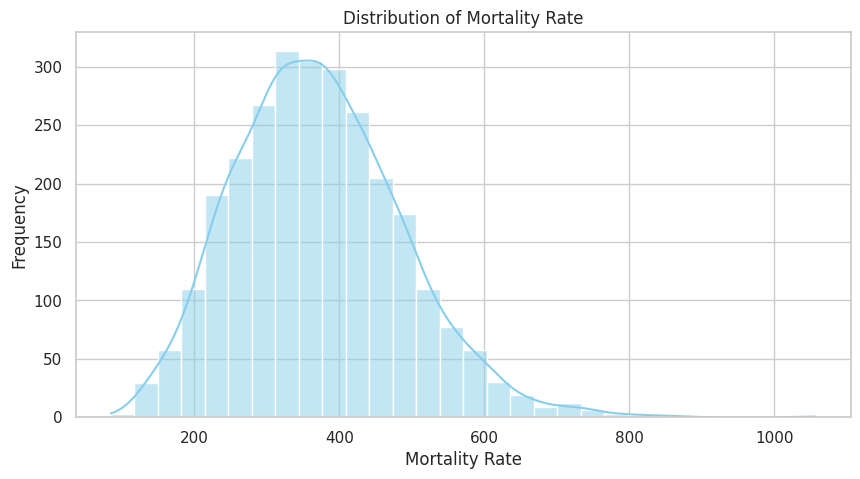

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(merged['MortalityRate'], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Mortality Rate")
plt.xlabel("Mortality Rate")
plt.ylabel("Frequency")
plt.show()

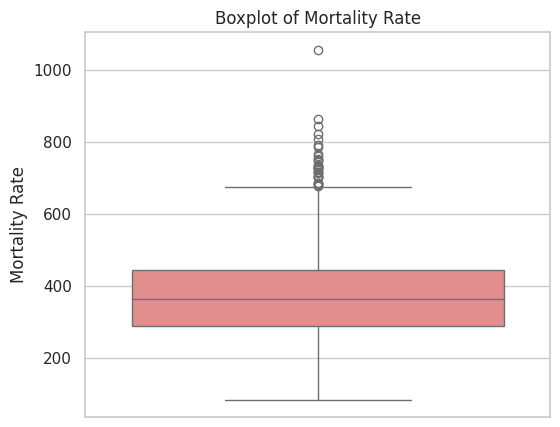

In [53]:
plt.figure(figsize=(6,5))
sns.boxplot(y=merged['MortalityRate'], color="lightcoral")
plt.title("Boxplot of Mortality Rate")
plt.ylabel("Mortality Rate")
plt.show()

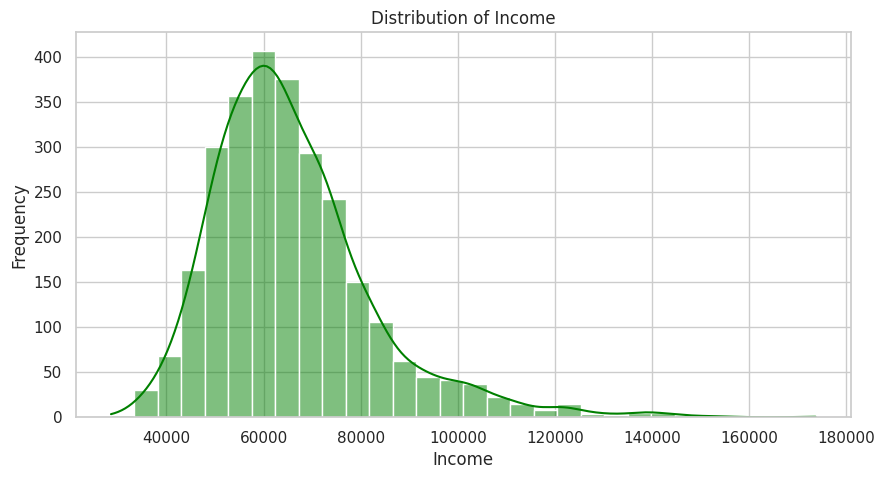

In [54]:
plt.figure(figsize=(10,5))
sns.histplot(merged['Income'], bins=30, kde=True, color="green")
plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

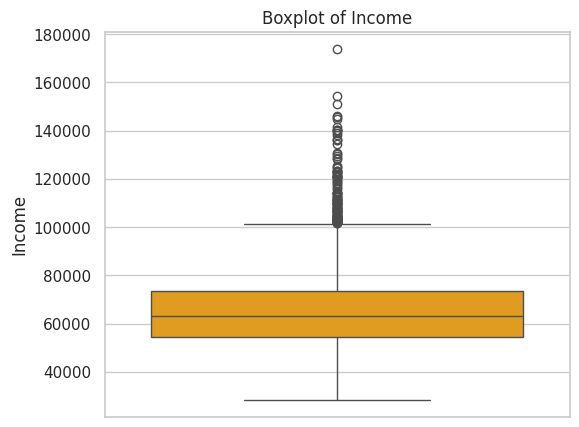

In [55]:
plt.figure(figsize=(6,5))
sns.boxplot(y=merged['Income'], color="orange")
plt.title("Boxplot of Income")
plt.ylabel("Income")
plt.show()

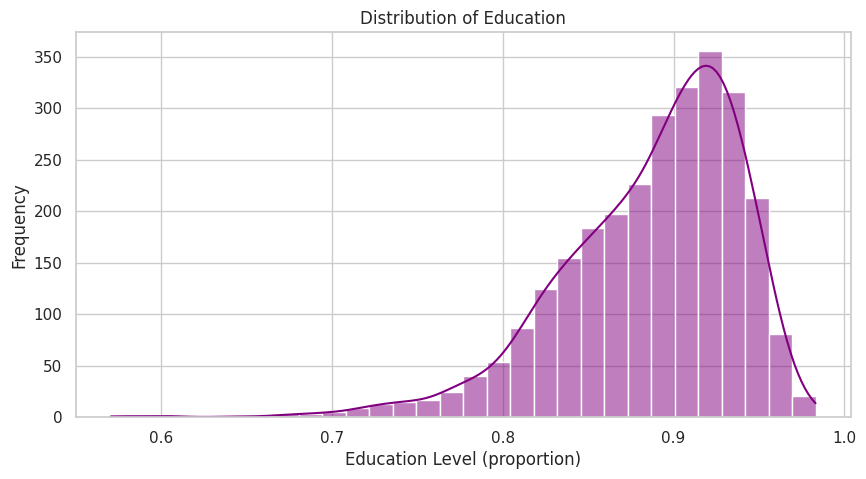

In [56]:
plt.figure(figsize=(10,5))
sns.histplot(merged['Education'], bins=30, kde=True, color="purple")
plt.title("Distribution of Education")
plt.xlabel("Education Level (proportion)")
plt.ylabel("Frequency")
plt.show()

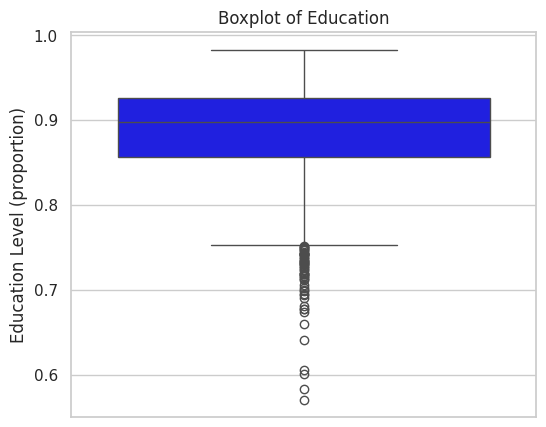

In [57]:
plt.figure(figsize=(6,5))
sns.boxplot(y=merged['Education'], color="blue")
plt.title("Boxplot of Education")
plt.ylabel("Education Level (proportion)")
plt.show()